# DS 3026: Final Project

### Reproducible Notebook

**Group:** Ben Berinsky, Will Wert, Carissa Chen, Mason Nicoletti

<br>

---

## I. Problem Formulation

- Clearly describe your dataset and context
- Define one inferential question (e.g., effect, difference, parameter)
- Define one predictive task (e.g., classification or regression)
- Clearly explain the difference between the two

<br>

### Dataset and Context

**Dataset:** Students_Performance_dataset.csv
- Contains student demographic information
- Many features
- Target Variable: GPA

**Context:**

Student performance is often measured through GPA, but this is impacted by a wide range of factors. Study habits, home/family life, access to resources, responsibilities outside of school, and a multitude of other influences impact grade point average. In this report, we analyze the relationship between various factors and GPA. The dataset contains information about roughly 1200 computer science and engineering students at a private institution in Bangladesh. Data was collected through an online survey form. The dataset contains 31 features, both academic and non-academic. Key fields include cumulative GPA, scholarship status, study hours per day, social media time, attendance, and more.

**Link to Data Source:**

[Students' Academic Performance Evaluation Dataset](https://data.mendeley.com/datasets/dc3797vf3t/1)

<br>

### Inference and Prediction

**Inferential Question:** 

Is there a credible difference between the mean cumulative grade point average of scholarship students and non-scholarship students for computer science and engineering students?

**Predictive Task:** 

Can we predict the cumulative grade point average of a new student based on the information present in the dataset, specifically lifestyle, demographic, and past academic information?

**Differentiation:**

The key distinction is that our inferential question focuses on estimating a specific population parameter (the true mean difference in GPA), whereas our predictive task focuses on minimizing error for individual observations (unseen students).

<br>

---

## Data Loading and Preprocessing

In [212]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

from scripts.data_prep import data_prep

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge, LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [213]:
# Load raw data

data_raw = pd.read_csv("./data/Students_Performance_dataset.csv")

In [214]:
# Preview data

data_raw.head()

,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


In [215]:
# Apply data prep function

data = data_prep(data_raw)

In [216]:
# Preview cleaned data

data.head()

,age,study_hours,study_seatings,social_media_hours,attendance,skill_hours,semester_gpa,cumulative_gpa,credits,family_income,...,skills_programming,skills_software_development,skills_web_development,interest_area_data_science,interest_area_hardware,interest_area_machine_learning,interest_area_networking,interest_area_other,interest_area_software,interest_area_ui/ux
0,24,3,2,5,90.0,2,2.68,3.15,75,25000,...,0,1,0,0,0,0,0,1,0,0
1,22,3,2,3,96.0,2,2.68,3.15,36,100000,...,0,0,1,0,0,0,0,1,0,0
2,21,3,3,3,80.0,1,2.68,3.15,50,50000,...,1,0,0,0,0,0,0,0,1,0
3,20,1,3,2,88.0,1,2.68,3.15,36,62488,...,1,0,0,0,0,0,0,0,0,0
4,22,3,1,2,80.0,1,2.68,3.15,36,50000,...,1,0,0,0,0,0,0,0,1,0


In [217]:
# View features

data.columns

Index(['age', 'study_hours', 'study_seatings', 'social_media_hours',
       'attendance', 'skill_hours', 'semester_gpa', 'cumulative_gpa',
       'credits', 'family_income', 'english_proficiency_basic',
       'english_proficiency_intermediate', 'health_issues_no',
       'health_issues_yes', 'health_issues_no', 'scholarship_yes',
       'gender_male', 'transportation_yes', 'disabilities_yes',
       'skills_cyber_security', 'skills_machine_learning', 'skills_networking',
       'skills_other', 'skills_programming', 'skills_software_development',
       'skills_web_development', 'interest_area_data_science',
       'interest_area_hardware', 'interest_area_machine_learning',
       'interest_area_networking', 'interest_area_other',
       'interest_area_software', 'interest_area_ui/ux'],
      dtype='object')

---

## II. Likelihood and Estimation

- Specify a statistical model (e.g., Bernoulli, Normal, Logistic)
- Write down the likelihood function (conceptually or mathematically)
- Compute or estimate parameters using MLE
- Visualize or interpret how the likelihood behaves

**Inferential Question:** Is there a credible difference between the mean cumulative grade point average of scholarship students and non-scholarship students for computer science and engineering students?

In [218]:
# Separate scholarship and non-scholarship students
non_scholarship = data[data['scholarship_yes'] == 0]["cumulative_gpa"]
scholarship = data[data['scholarship_yes'] == 1]["cumulative_gpa"]

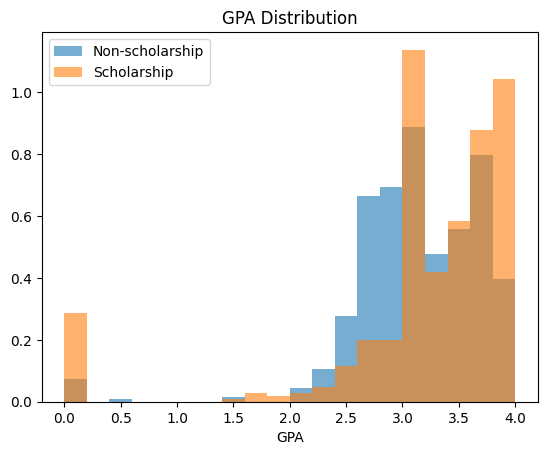

In [219]:
# Visualize gpa distributions

plt.figure()
plt.hist(non_scholarship, bins=20, alpha=0.6, density=True, label="Non-scholarship")
plt.hist(scholarship, bins=20, alpha=0.6, density=True, label="Scholarship")
plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.legend()
plt.savefig("./figures/gpa_distribution.png")
plt.show()

### Specify a statistical model

Statistical Model: **Normal Distribution**

The distribution of GPA for students is best modeled using a Normal distribution. After separating students into two groups, one for scholarship students and the other for non-scholarship students, we can assume both groups follow a Normal distribution with their own mean and standard deviation.

### Likelihood Function

**Conceptually:** What is the plausibility of the parameter values for the mean GPA and standard deviation for non-scholarship students and the mean GPA and standard deviation for scholarship students given the observed student performance data?

Let *x*<sub>*i*</sub> denote a student.

$$
x_i \sim 
\begin{cases}
\mathcal{N}(\mu_0, \sigma_0^2), & \text{if } i \in \text{group 0 (non-scholarship)} \\
\mathcal{N}(\mu_1, \sigma_1^2), & \text{if } i \in \text{group 1 (scholarship)}
\end{cases}
$$

**Mathematically:**

Likelihood Function:

$$
L(\mu_0, \mu_1, \sigma_0^2, \sigma_1^2) = 
\prod_{i \in \text{group 0}} f(x_i \mid \mu_0, \sigma_0^2)
\times
\prod_{i \in \text{group 1}} f(x_i \mid \mu_1, \sigma_1^2)
$$

Applying the Normal Density statistical model:

$$
f(x \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} 
\exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

### Estimate parameters using MLE

In [220]:
# Estimate parameters using MLE

# Compute parameters
mu_0, sigma_0 = non_scholarship.mean(), non_scholarship.std(ddof=0)
mu_1, sigma_1 = scholarship.mean(), scholarship.std(ddof=0)

p_0 = len(non_scholarship) / len(data)
p_1 = len(scholarship) / len(data)

# Create a mle df
mle_df = pd.DataFrame({
    "Non-scholarship": [mu_0, sigma_0, p_0],
    "Scholarship": [mu_1, sigma_1, p_1]},
    index=['Mean', 'Standard Deviation', 'Percentage']
    )

print("Parameter Estimates:")
print(mle_df)

Parameter Estimates:
                    Non-scholarship  Scholarship
Mean                       3.134672     3.205430
Standard Deviation         0.599609     0.905613
Percentage                 0.561609     0.438391


### Visualize and interpret likelihood

In [221]:
# Define a log-likelihood function

def log_likelihood(mu, data, sigma):
    log_likelihood = -0.5 * np.sum(((data - mu) / sigma)**2) - len(data) * np.log(sigma)
    return log_likelihood

In [222]:
# Create a range of mu values
mu_0_vals = np.linspace(mu_0 - 1, mu_0 + 1, 100)
mu_1_vals = np.linspace(mu_1 - 1, mu_1 + 1, 100)

# Create a list of log-likelihoods
log_likelihood_mu_0 = [log_likelihood(mu, non_scholarship, sigma_0) for mu in mu_0_vals]
log_likelihood_mu_1 = [log_likelihood(mu, scholarship, sigma_0) for mu in mu_0_vals]

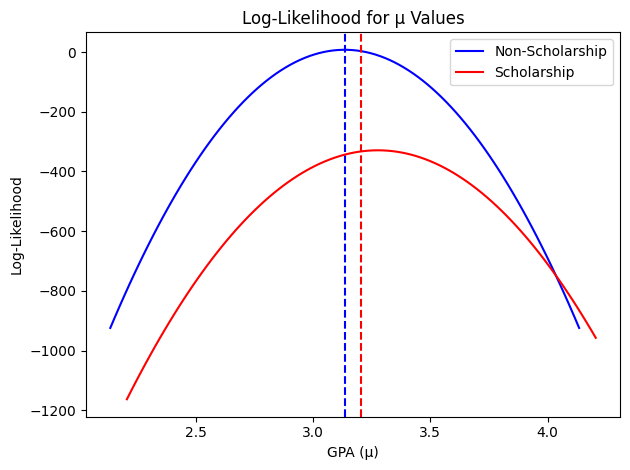

In [223]:
# Plot likelihood values

plt.figure()

plt.plot(mu_0_vals, log_likelihood_mu_0, color='Blue', label='Non-Scholarship')
plt.axvline(mu_0, linestyle='--', color='Blue')

plt.plot(mu_1_vals, log_likelihood_mu_1, color='Red', label='Scholarship')
plt.axvline(mu_1, linestyle='--', color='Red')

plt.title("Log-Likelihood for μ Values")
plt.xlabel("GPA (μ)")
plt.ylabel("Log-Likelihood")
plt.legend()
plt.tight_layout()
plt.savefig("./figures/log_likelihood_plot.png")
plt.show()

#### Interpretation of Likelihood

In the visualization above, the log-likelihoods are plotted for the non-scholarship and scholarship groups. The curves trace the likelihood of true mean GPA for a student occurring at that GPA value, which runs along the x-axis. The likelihoods are maximized at the sample means (μ₀ and μ₁). Both curves are similar in shape, however, the non-scholarship curve has a sharper peak that also has a greater log-likelihood. This indicates the mean GPA for non-scholarship students was estimated with greater certainty.

---

## III. Frequentist Inference

- Construct at least one confidence interval (preferably bootstrap)
- Interpret the interval in context
- (Optional) Perform a hypothesis-style comparison if appropriate

**Important:**

- Focus on interpretation, not formulas
- Explain what uncertainty means in your problem

**Question:** Is there a statistically significant difference between the mean GPA of scholarship students and non-scholarship students in the wider student population?

In [224]:
# Split into the two groups of interest
scholarship = data[data['scholarship_yes'] == 1]['cumulative_gpa']
non_scholarship = data[data['scholarship_yes'] == 0]['cumulative_gpa']

print(f"Scholarship students:     n = {len(scholarship)}, mean GPA = {scholarship.mean():.4f}, std = {scholarship.std():.4f}")
print(f"Non-scholarship students: n = {len(non_scholarship)}, mean GPA = {non_scholarship.mean():.4f}, std = {non_scholarship.std():.4f}")
print(f"\nObserved difference in means (scholarship - non-scholarship): {scholarship.mean() - non_scholarship.mean():.4f}")

Scholarship students:     n = 523, mean GPA = 3.2054, std = 0.9065
Non-scholarship students: n = 670, mean GPA = 3.1347, std = 0.6001

Observed difference in means (scholarship - non-scholarship): 0.0708


### Normal Approximation Confidence Interval

With group sizes of over 500 students each, the Central Limit Theorem ensures the sampling distribution of the mean difference is approximately normal. This lets us use a simple **z-interval** to construct a 95% CI for the true difference in mean GPA.

In [225]:
# --- Normal approximation confidence interval ---

n_s  = len(scholarship)
n_ns = len(non_scholarship)

mean_diff = scholarship.mean() - non_scholarship.mean()
se_diff   = np.sqrt(scholarship.var(ddof=1)/n_s + non_scholarship.var(ddof=1)/n_ns)

z_crit  = 1.96  # 95% CI, two-tailed
ci_low  = mean_diff - z_crit * se_diff
ci_high = mean_diff + z_crit * se_diff

print(f"Observed mean GPA difference (scholarship - non-scholarship): {mean_diff:.4f}")
print(f"Standard error of the difference:                            {se_diff:.4f}")
print(f"\n95% Normal Approximation CI: ({ci_low:.4f}, {ci_high:.4f})")

Observed mean GPA difference (scholarship - non-scholarship): 0.0708
Standard error of the difference:                            0.0459

95% Normal Approximation CI: (-0.0192, 0.1608)


### Visualizing the Normal Approximation CI

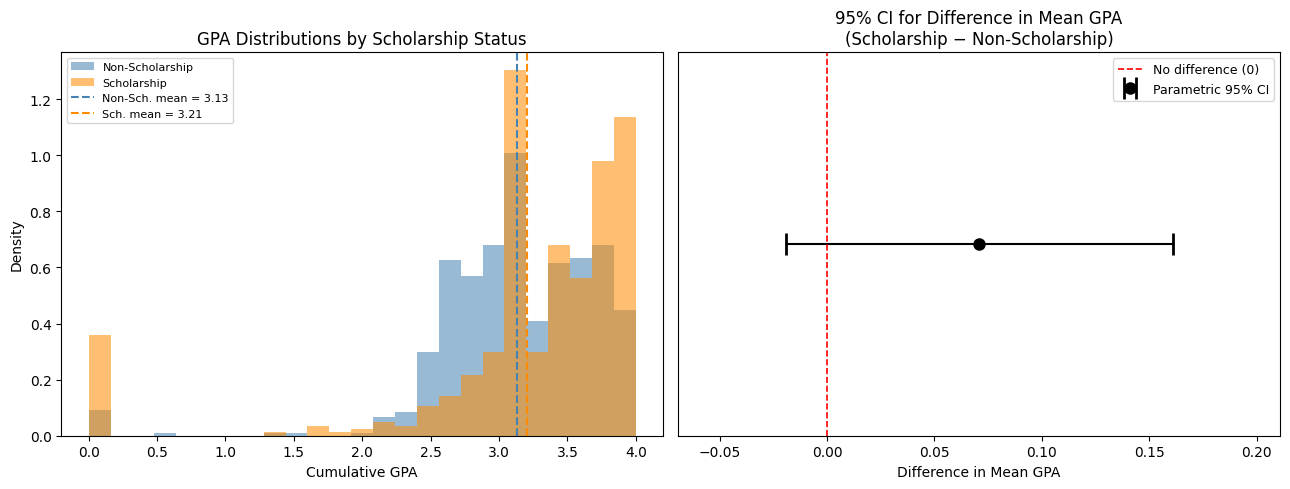

In [226]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: GPA distributions for both groups
ax = axes[0]
ax.hist(non_scholarship, bins=25, alpha=0.55, density=True, label='Non-Scholarship', color='steelblue')
ax.hist(scholarship, bins=25, alpha=0.55, density=True, label='Scholarship', color='darkorange')
ax.axvline(non_scholarship.mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f'Non-Sch. mean = {non_scholarship.mean():.2f}')
ax.axvline(scholarship.mean(), color='darkorange', linestyle='--', linewidth=1.5, label=f'Sch. mean = {scholarship.mean():.2f}')
ax.set_title('GPA Distributions by Scholarship Status')
ax.set_xlabel('Cumulative GPA')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Right: CI plot for the difference in means
ax2 = axes[1]
ax2.errorbar(
    x=[mean_diff], y=[0],
    xerr=[[mean_diff - ci_low], [ci_high - mean_diff]],
    fmt='o', color='black', capsize=8, capthick=2, markersize=8, label='Parametric 95% CI'
)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.2, label='No difference (0)')
ax2.set_title('95% CI for Difference in Mean GPA\n(Scholarship − Non-Scholarship)')
ax2.set_xlabel('Difference in Mean GPA')
ax2.set_yticks([])
ax2.legend(fontsize=9)
ax2.set_xlim(ci_low - 0.05, ci_high + 0.05)

plt.tight_layout()
plt.savefig("./figures/mean_gpa_ci_and_distribution.png")
plt.show()

#### Interpretation of Normal Approximation CI

The 95% CI gives a plausible range for the **true population difference** in mean GPA between scholarship and non-scholarship students. If the interval does not include 0, the observed difference is unlikely to be explained by chance alone. If it includes 0, we cannot rule out that the true population difference is zero.

The width of the interval reflects **uncertainty due to sampling** — with a larger or more representative sample we would expect a narrower interval.

### Bootstrap Confidence Interval

The normal approximation CI relies on the CLT holding for our sample sizes. A **bootstrap CI** makes no distributional assumptions at all — it estimates the sampling distribution directly by resampling from the data with replacement.

If the two intervals agree closely, it gives us additional confidence in the result.

In [227]:
# --- Bootstrap confidence interval ---

np.random.seed(42)
n_bootstrap = 5000
bootstrap_diffs = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    # Resample with replacement from each group
    boot_s  = np.random.choice(scholarship, size=n_s, replace=True)
    boot_ns = np.random.choice(non_scholarship, size=n_ns, replace=True)
    bootstrap_diffs[i] = boot_s.mean() - boot_ns.mean()

boot_ci_low, boot_ci_high = np.percentile(bootstrap_diffs, [2.5, 97.5])

print(f"Bootstrap mean of differences:     {bootstrap_diffs.mean():.4f}")
print(f"95% Bootstrap CI: ({boot_ci_low:.4f}, {boot_ci_high:.4f})")
print()
print(f"Parametric CI:    ({ci_low:.4f}, {ci_high:.4f})")
print(f"Bootstrap CI:     ({boot_ci_low:.4f}, {boot_ci_high:.4f})")

Bootstrap mean of differences:     0.0708
95% Bootstrap CI: (-0.0197, 0.1575)

Parametric CI:    (-0.0192, 0.1608)
Bootstrap CI:     (-0.0197, 0.1575)


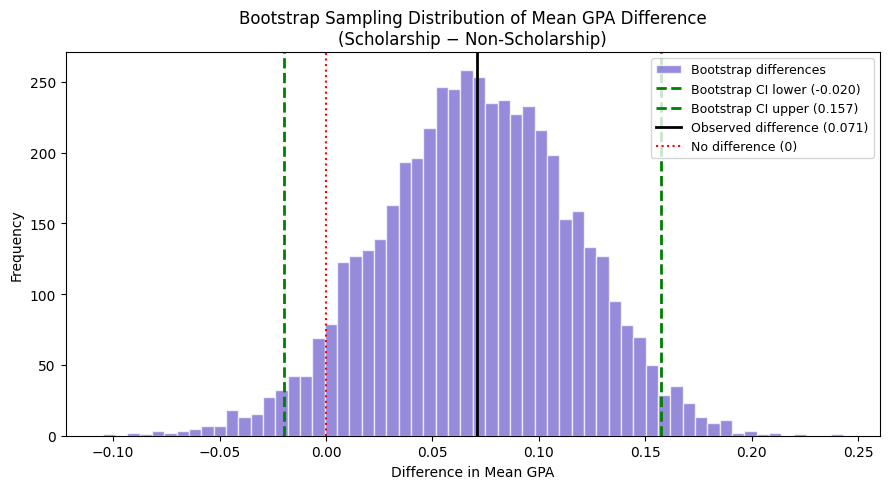

In [228]:
# Visualize the bootstrap sampling distribution
plt.figure(figsize=(9, 5))
plt.hist(bootstrap_diffs, bins=60, color='slateblue', alpha=0.7, edgecolor='white', label='Bootstrap differences')
plt.axvline(boot_ci_low,  color='green', linestyle='--', linewidth=2, label=f'Bootstrap CI lower ({boot_ci_low:.3f})')
plt.axvline(boot_ci_high, color='green', linestyle='--', linewidth=2, label=f'Bootstrap CI upper ({boot_ci_high:.3f})')
plt.axvline(mean_diff,    color='black', linestyle='-',  linewidth=2, label=f'Observed difference ({mean_diff:.3f})')
plt.axvline(0,            color='red',   linestyle=':',  linewidth=1.5, label='No difference (0)')
plt.title('Bootstrap Sampling Distribution of Mean GPA Difference\n(Scholarship − Non-Scholarship)')
plt.xlabel('Difference in Mean GPA')
plt.ylabel('Frequency')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("./figures/bootstrap_distribution.png")
plt.show()

#### Interpretation of Bootstrap CI

The histogram shows the **bootstrap sampling distribution** — a simulated picture of how much the estimated mean GPA difference could vary across different random samples. The green dashed lines mark the 2.5th and 97.5th percentiles, forming the 95% bootstrap CI. The close agreement between the parametric CI and the bootstrap CI strengthens our conclusion: neither approach is sensitive to assumptions the other might be violating.

### What Uncertainty Means Here

Frequentist inference quantifies **uncertainty due to random sampling**. Our dataset is a snapshot of students from one institution; we want to draw conclusions about all students in the broader population. The confidence intervals capture that uncertainty.

The observed difference is small in absolute terms (~0.07 GPA points). Both CIs span a range that includes zero, meaning the data are consistent with there being no real difference in the population. Statistical significance and practical significance are not the same thing — the frequentist framework helps us resist over-interpreting a small observed difference in a finite sample as a definitive truth about the population.

In [229]:
# Final summary printout
print("=" * 60)
print("FREQUENTIST INFERENCE SUMMARY")
print("=" * 60)
print(f"Observed difference (scholarship - non-scholarship):  {mean_diff:+.4f} GPA points")
print()
print(f"95% Normal Approximation CI:  ({ci_low:.4f}, {ci_high:.4f})")
print(f"95% Bootstrap CI:             ({boot_ci_low:.4f}, {boot_ci_high:.4f})")
print()
if ci_low < 0 < ci_high:
    print("Conclusion: Both CIs contain 0 — we cannot rule out that the true")
    print("difference in population mean GPA is zero.")
else:
    print("Conclusion: Both CIs exclude 0 — statistically significant difference.")

FREQUENTIST INFERENCE SUMMARY
Observed difference (scholarship - non-scholarship):  +0.0708 GPA points

95% Normal Approximation CI:  (-0.0192, 0.1608)
95% Bootstrap CI:             (-0.0197, 0.1575)

Conclusion: Both CIs contain 0 — we cannot rule out that the true
difference in population mean GPA is zero.


---

## IV. Bayesian Estimation

- Choose a reasonable prior (explain your choice)
- Compute or simulate a posterior (grid or simple approach is fine)
- Report a credible interval
- Compare your Bayesian results to frequentist results


### Inferential

**Inferential Question:** Is there a credible difference between the mean cumulative grade point average of scholarship students and non-scholarship students for computer science and engineering students?

### Computation Process

In [230]:
# getting scholarship yes count
scholarship_count = data['scholarship_yes'].sum()
no_scholarship_count = len(data) - scholarship_count 
print(f"Number of students with scholarship: {scholarship_count}, without scholarship: {no_scholarship_count}")

Number of students with scholarship: 523, without scholarship: 670


Based on the normal-normal conjugate, 

Posterior Distribution of Parameter: 
$$\theta | x \sim N\left( \frac{\frac{n\bar{x}}{\sigma^2} + \frac{\mu}{\tau^2}}{\frac{n}{\sigma^2} + \frac{1}{\tau^2}}, \frac{1}{\frac{n}{\sigma^2} + \frac{1}{\tau^2}} \right)$$

Bayesian Point Estimate: 
$$\hat{\theta}_{BE} = \left( \frac{n\tau^2}{n\tau^2 + \sigma^2} \right)\bar{x} + \left( \frac{\sigma^2}{n\tau^2 + \sigma^2} \right)\mu$$

Where: 
- $\bar{x}$: Sample Mean (The observed difference in our dataset)
- $n$: Sample Size.$\sigma^2$: Data Variance (Assumed known from the sample)
- $\mu$: Prior Mean (Our initial belief, e.g., $0$ for no difference)
- $\tau^2$: Prior Variance (How certain we are of our prior belief)
- $\frac{1}{\sigma^2}$: Sample Precision (inverse of variance)
- $\frac{1}{\tau^2}$: Prior Precision (inverse of variance)

Finding parameter (diff between scholarship and no scholarship GPA)

In [231]:
#scholarship_students = student_data[student_data['scholarship'] == 'Yes']
scholarship_students = data[data['scholarship_yes'] == 1]
no_scholarship_students = data[data['scholarship_yes'] == 0]
mean_scholarship_gpa = scholarship_students['cumulative_gpa'].mean()
mean_no_scholarship_gpa = no_scholarship_students['cumulative_gpa'].mean()
gpa_diff = mean_scholarship_gpa - mean_no_scholarship_gpa
print(f"Mean GPA for scholarship students: {mean_scholarship_gpa:.2f}")
print(f"Mean GPA for non-scholarship students: {mean_no_scholarship_gpa:.2f}")
print(f"Difference in mean GPA: {gpa_diff:.2f}")

Mean GPA for scholarship students: 3.21
Mean GPA for non-scholarship students: 3.13
Difference in mean GPA: 0.07


Finding values for variables

In [232]:
x_bar = gpa_diff
n = len(data)
# using sample variance as an estimate for population variance
sigma_sq = data['cumulative_gpa'].var()

In [233]:
sigma_sq

np.float64(0.5631604483930309)

For our prior distribution we assume there is no difference between cumulative GPA for students on scholarship and not on scholarship. This means that our prior belief is there is no effect of scholarship status on cumulative GPA. Because of this we use $\mu$ = 0 and $\sigma$ = 0.5.  

In [234]:
# setting prior beliefs
mu = 0 
tau_sq = 0.5**2 

# calculating precision (1 / Variance)
prior_precision = 1 / tau_sq
sample_precision = n / sigma_sq
posterior_precision = prior_precision + sample_precision

Computing posterior metrics 
- post_mean = [(sample_mean * sample_prec) + (prior_mean * prior_prec)] / total_prec

In [235]:
# mean
post_mu = ((x_bar * sample_precision) + (mu * prior_precision) ) / posterior_precision

# variance/std
post_var = 1 / posterior_precision
post_std = np.sqrt(post_var)

Now that posterior metrics have been calculated we can compute the credible interval

In [236]:
post_std

np.float64(0.021706320784384486)

In [237]:
lower, upper = norm.interval(0.95, loc=post_mu, scale=post_std)

print(f"Posterior Mean: {post_mu:.4f}")
print(f"95% Credible Interval: ({lower:.4f}, {upper:.4f})")

Posterior Mean: 0.0706
95% Credible Interval: (0.0281, 0.1132)


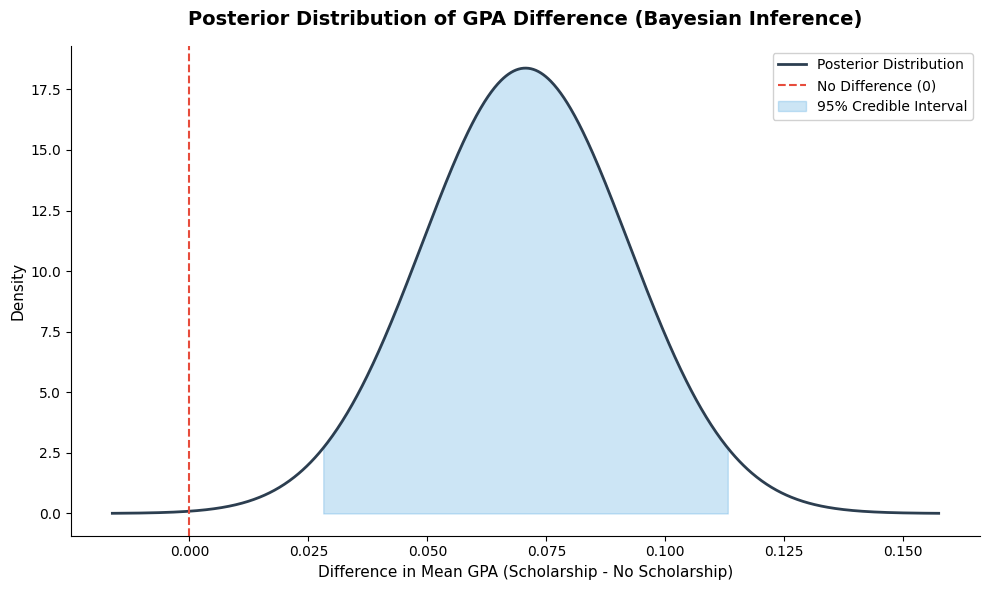

In [238]:
x = np.linspace(post_mu - 4*post_std, post_mu + 4*post_std, 1000)
y = norm.pdf(x, loc=post_mu, scale=post_std)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Posterior Distribution', color='#2c3e50', linewidth=2)
plt.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=1.5, label='No Difference (0)')
plt.fill_between(x, y, where=(x >= lower) & (x <= upper), color='#3498db', alpha=0.25, label='95% Credible Interval')
plt.title('Posterior Distribution of GPA Difference (Bayesian Inference)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Difference in Mean GPA (Scholarship - No Scholarship)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(framealpha=0.9, fontsize=10)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("./figures/bayesian_posterior_distribution.png")
plt.show()

### Interpretation

The posterior mean we found was 0.07 and the 95% credible interval was [0.028, 0.113]. Since the 95% credible interval does not contain 0 we conclude that there is an effect of scholarship status on cumulative GPA for college students. This means that there is a 95% posterior probability that the true difference of cumulative GPA for college students who are on scholarship vs. those who are not on scholarship (scholarship - non scholarship) is between 0.028 and 0.113. These findings show that there is strong posterior evidence that students on scholarship have higher GPAs.

### Predictive

To what extent can a Bayesian linear regression model accurately forecast individual student GPAs using scholarship status, study hours, and demographic factors as predictors?

### Building Model

In [239]:
student_data = data.dropna()
X = student_data.drop(['cumulative_gpa', 'semester_gpa'], axis=1)
y = student_data['cumulative_gpa']

In [240]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fitting bayesian ridge model
model = BayesianRidge()
model.fit(X_train, y_train)

# Generating predictions and uncertainty estimates
y_pred, y_std = model.predict(X_test, return_std=True)

# Evaluating
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")

Root Mean Squared Error: 0.6066
R-squared Score: 0.1051


### Prediction Interval

In [241]:
# Select a random sample student from test set 
sample_index = np.random.choice(len(y_pred))
individual_pred = y_pred[sample_index]
individual_std = y_std.iloc[sample_index]

# Calculate the 95% Prediction Interval
lower_pi = individual_pred - (1.96 * individual_std)
upper_pi = individual_pred + (1.96 * individual_std)

print(f"Prediction for Student {sample_index}:")
print(f"Expected Cumulative GPA: {individual_pred:.2f}")
print(f"95% Prediction Interval: ({lower_pi:.2f}, {upper_pi:.2f})")
print(f"Actual GPA: {y_test.iloc[sample_index]:.2f}")

Prediction for Student 35:
Expected Cumulative GPA: 3.03
95% Prediction Interval: (1.42, 4.64)
Actual GPA: 2.01


Generally, our prediction intervals are fairly wide and not very informative. This is because the model performed poorly.

---

# V. Resampling and Simulation

- Implement a bootstrap (for mean, proportion, or model)
- Explain what the variability in your results means

**Research Question:** Is there a credible difference between the mean GPA of scholarship students and non-scholarship students in the wider student population

A single boostrap is implemented to perform a hypothesis test.

H0: There is no difference between mean GPA of scholarship and nonscholarship students

Ha: There is a difference between mean GPA of scholarship and nonscholarship students

After bootstrapping to simulate different groups of students from the original sample, the mean GPA between scholar and nonscholarships students are compared for each set, then form a 95% confidence interval to determine if there is a significance.

In [242]:
scholar = data[data['scholarship_yes']==1]['cumulative_gpa'].reset_index(drop=True)
nonscholar = data[data['scholarship_yes']==0]['cumulative_gpa'].reset_index(drop=True)

n_scholar=len(scholar)
n_nonscholar=len(nonscholar)
iterations=1000
rng=np.random.default_rng(2478)
means=np.full(iterations,np.nan)
for i in range(iterations):
  idx_s=rng.integers(0,n_scholar,size=n_scholar)
  idx_ns=rng.integers(0,n_nonscholar,size=n_nonscholar)

  mean_s=scholar.iloc[idx_s].mean()
  mean_ns=nonscholar.iloc[idx_ns].mean()
  means[i]=mean_s-mean_ns
ci=np.percentile(means,[2.5,97.5])
print(f"Confidence Interval: {ci}")

Confidence Interval: [-0.01637045  0.16358325]


Average GPA Difference: 0.07210575711309605


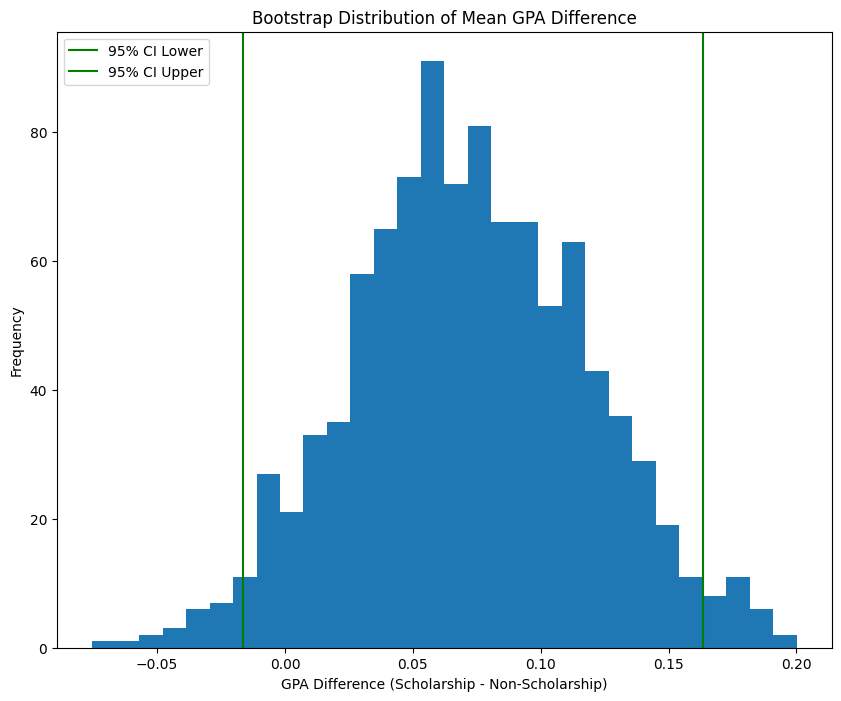

In [243]:
print(f"Average GPA Difference: {means.mean()}")
plt.figure(figsize=(10,8))
plt.hist(means,bins=30)
plt.axvline(ci[0], color='green', label='95% CI Lower')
plt.axvline(ci[1], color='green', label='95% CI Upper')
plt.title('Bootstrap Distribution of Mean GPA Difference')
plt.xlabel('GPA Difference (Scholarship - Non-Scholarship)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig("./figures/resampling_bootstrap_distribution.png")
plt.show()

### Interpretation

With confidence intervals, if 0 is contained in the interval, it means there is no statistically significant difference. The interval of -0.0232 and 0.157 contains 0, meaning we fail to reject H0 and there is no statistical significance between GPAs of scholarship and nonscholarship students.

The variability in the results represents the overall uncertainty in the model. Here, the dataset only provides a snapshot of the overall national or global student population.